# Customer Churn Prediction using Decision Tree and Random Forest

The objective of this project is to predict customer churn using the IBM Telco Customer Churn dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# Dataset Description

The IBM Telco Customer Churn dataset contains information about customers of a telecommunications company.

## Target Variable

**Churn**

- Yes = Customer left the company
- No = Customer stayed with the company

## Important Features

- gender
- SeniorCitizen
- Partner
- Dependents
- tenure
- Contract
- InternetService
- PaymentMethod
- MonthlyCharges
- TotalCharges

The goal is to predict whether a customer will churn or not.

In [3]:
df = pd.read_csv("Telco_customer_churn.csv")
print("First 5 Rows:")
print(df.head())
print("\nDataset Shape:")
print(df.shape)


First 5 Rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies       

# Dataset Information

This step displays information about the dataset such as:

- Number of rows and columns
- Data types of features
- Missing values

In [ ]:
print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

df.describe(include="all")


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


# Data Cleaning and Preprocessing

The following preprocessing steps are performed:

1. Remove customerID because it is only an identifier.
2. Convert TotalCharges into numeric format.
3. Handle missing values using median imputation.
4. Remove duplicate records.
5. Encode the target variable.
6. Apply One-Hot Encoding to categorical features.

In [ ]:
# Remove customerID
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Encode target variable
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# One-Hot Encoding
df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (5616, 30)
Testing Shape : (1405, 30)


# Decision Tree Classifier

Decision Tree creates a tree-like structure by splitting the data based on important features.

It is easy to understand and visualize but may suffer from overfitting.

In [ ]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Training Accuracy:")
print(dt.score(X_train, y_train))

print("\nDecision Tree Testing Accuracy:")
print(dt.score(X_test, y_test))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Training Accuracy:
0.9976851851851852

Decision Tree Testing Accuracy:
0.7202846975088968

Confusion Matrix:
[[830 203]
 [190 182]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1033
           1       0.47      0.49      0.48       372

    accuracy                           0.72      1405
   macro avg       0.64      0.65      0.64      1405
weighted avg       0.72      0.72      0.72      1405



# Decision Tree Visualization

The tree visualization helps understand how the model makes decisions by splitting the data into different branches.

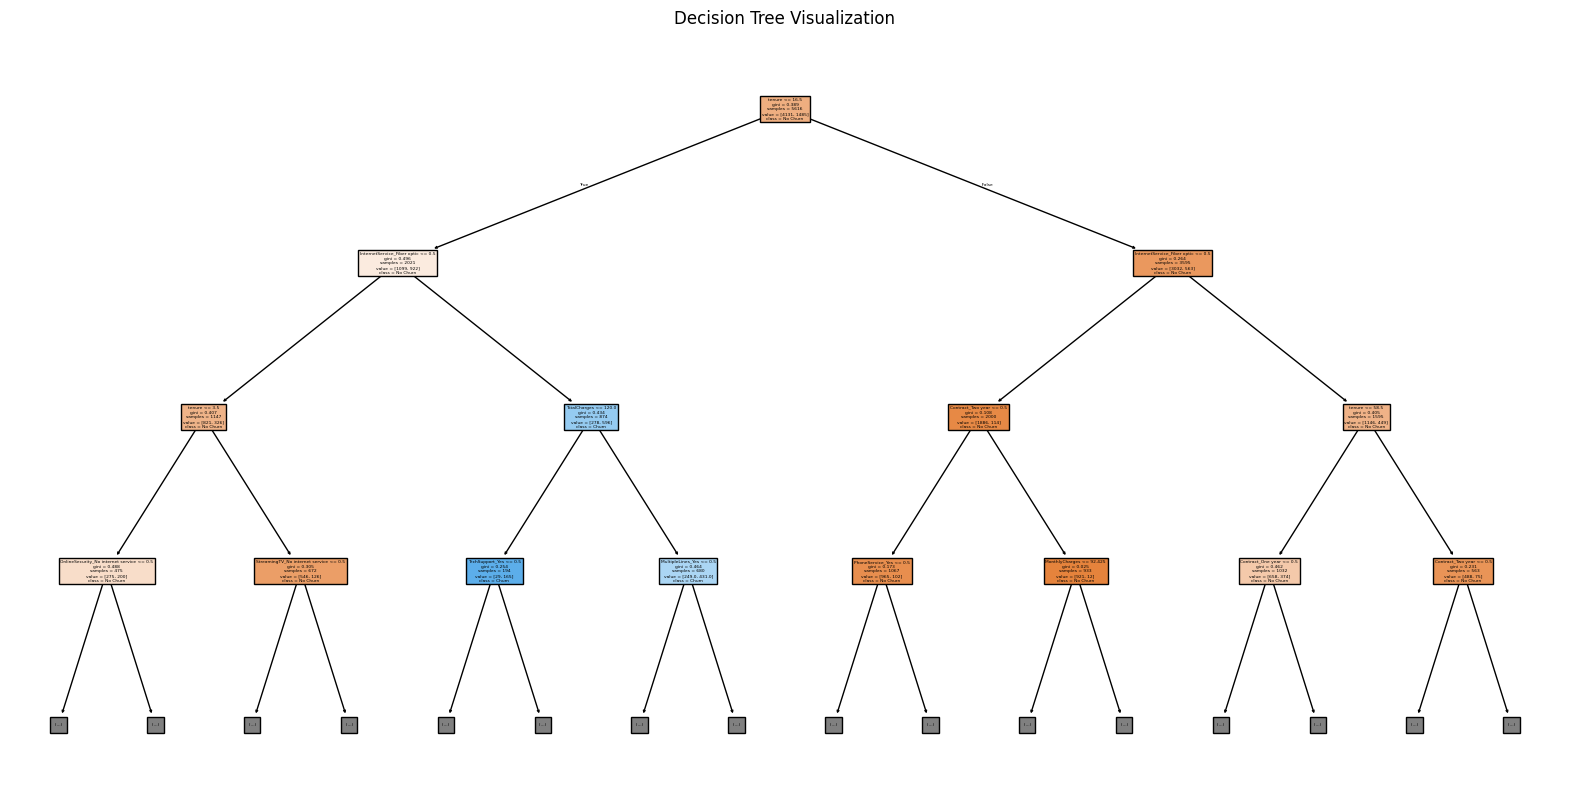

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    max_depth=3
)

plt.title("Decision Tree Visualization")
plt.show()

# Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

It reduces overfitting and usually provides better performance than a single Decision Tree.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Training Accuracy:")
print(rf.score(X_train, y_train))

print("\nRandom Forest Testing Accuracy:")
print(rf.score(X_test, y_test))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Training Accuracy:
0.9976851851851852

Random Forest Testing Accuracy:
0.7758007117437722

Confusion Matrix:
[[925 108]
 [207 165]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.85      1033
           1       0.60      0.44      0.51       372

    accuracy                           0.78      1405
   macro avg       0.71      0.67      0.68      1405
weighted avg       0.76      0.78      0.76      1405



# Model Comparison

The accuracy of both models is compared to determine which model performs better.

In [ ]:
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_acc, rf_acc]
})

comparison

,Model,Accuracy
0,Decision Tree,0.720285
1,Random Forest,0.775801


# Feature Importance using Decision Tree

Feature importance shows which features contribute the most to predicting customer churn.

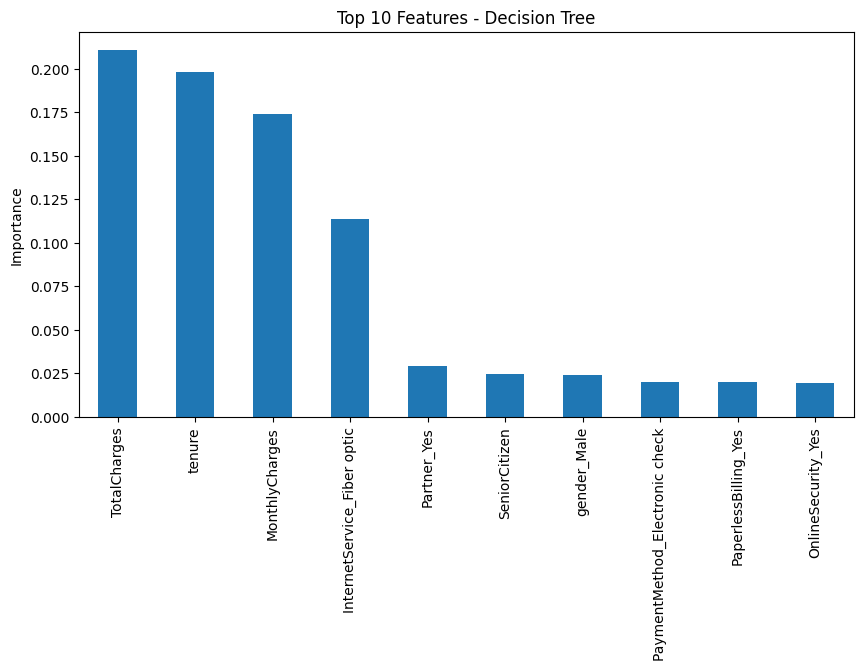

In [ ]:
dt_importance = pd.Series(
    dt.feature_importances_,
    index=X.columns
)

dt_importance = dt_importance.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
dt_importance.plot(kind="bar")
plt.title("Top 10 Features - Decision Tree")
plt.ylabel("Importance")
plt.show()

# Feature Importance using Random Forest

Random Forest provides a more reliable estimate of feature importance by averaging the importance across multiple trees.

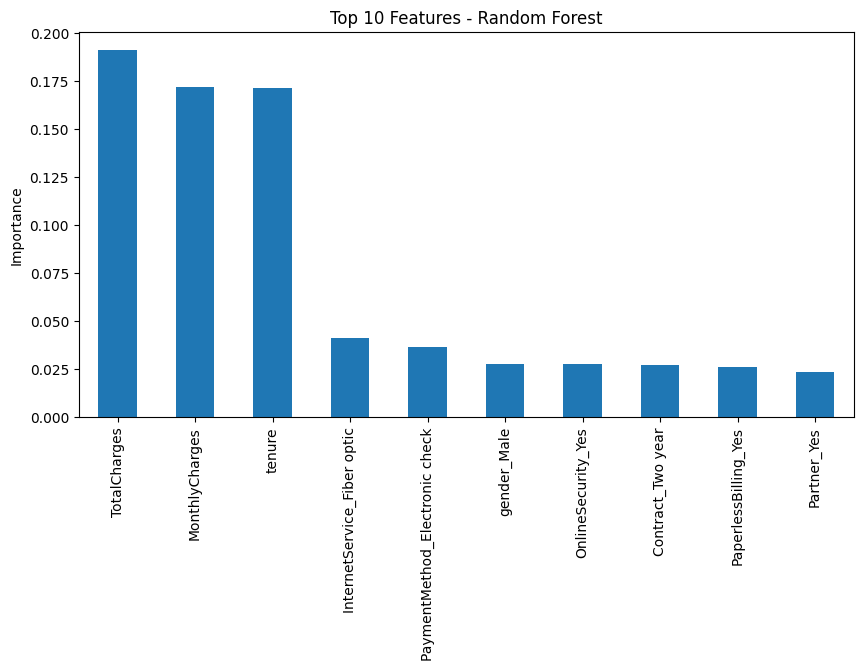

In [ ]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

rf_importance = rf_importance.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
rf_importance.plot(kind="bar")
plt.title("Top 10 Features - Random Forest")
plt.ylabel("Importance")
plt.show()

# Conclusion

In this project, Decision Tree and Random Forest classifiers were trained on the IBM Telco Customer Churn dataset.

## Observations

- Decision Tree is simple and easy to interpret.
- Decision Tree tends to overfit the training data.
- Random Forest reduces overfitting using ensemble learning.
- Random Forest generally achieves better testing accuracy.
- Contract type, tenure, MonthlyCharges, and TotalCharges are among the most important predictors of customer churn.

## Final Result

Random Forest performed better than a single Decision Tree and is therefore the preferred model for customer churn prediction.